In [1]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

In [8]:
# without attention
emul_past = "../plotting_data/CMIP6/corrdiff/past/*.npy"
gcm_past = "../plotting_data/CMIP6/GCM/past/*.npy"
# 90-99
gcm_future = "../plotting_data/CMIP6/GCM/future/*.npy"
emul_future = "../plotting_data/CMIP6/corrdiff/future/*.npy"

# with attention
# 30-39
rcm_past_id21 = "../plotting_data/orig_RCM_30-39/id011/*.npy"
emul_past_id21 = "../plotting_data/CMIP6/corrdiff_id021/future/*.npy"
gcm_past_id21 = "../plotting_data/GCM/*.npy"
# 90-99
rcm_future_id21 = "../plotting_data/orig_RCM/*.npy"
gcm_future_id21 = "../plotting_data/GCM/90-99/*.npy"
emul_future_id21 = "../plotting_data/CMIP6/corrdiff_id021/future/*.npy"

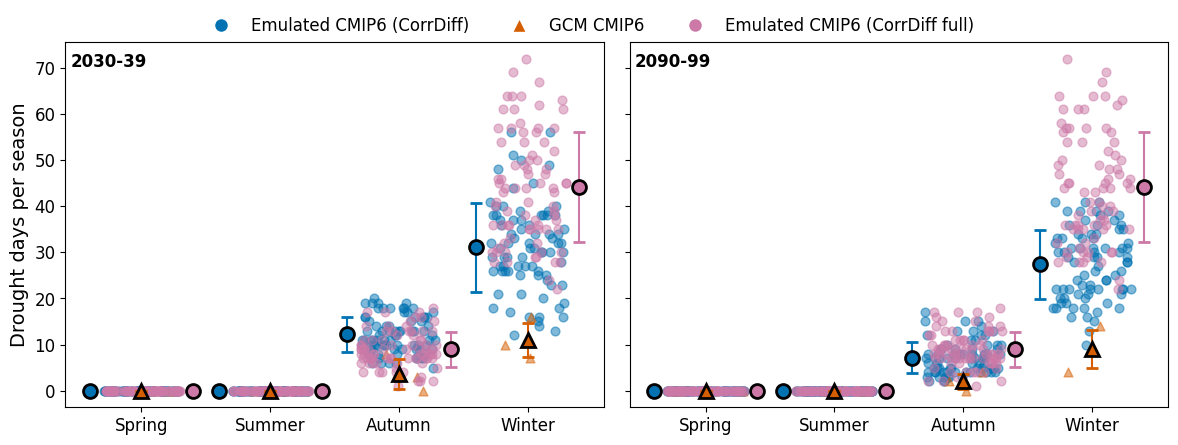

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from matplotlib.lines import Line2D

seed = 42
rng = np.random.default_rng(seed)

# --- File paths ---
emul_past = sorted(
    glob.glob(emul_past
    )
)
gcm_past = sorted(
    glob.glob(
        gcm_past
    )
)

emul_future = sorted(
    glob.glob(
        emul_future
    )
)
gcm_future = sorted(
    glob.glob(
        gcm_future
    )
)

emul_past_id21 = sorted(
    glob.glob(
        emul_past_id21
    )
)

emul_future_id21 = sorted(
    glob.glob(
        emul_future_id21
    )
)

# --- Styles for 5 groups ---
styles = {
    "Emulated CMIP6 (CorrDiff)": dict(color="#0072B2", marker="o", alpha=0.5),
    "GCM CMIP6": dict(color="#D55E00", marker="^", alpha=0.5),
    "Emulated CMIP6 (CorrDiff full)": dict(color="#CC79A7", marker="o", alpha=0.5),
}


def load_array(path, reorder=True):
    arr = np.load(path, allow_pickle=True)
    if isinstance(arr, dict):
        arr = list(arr.values())[0]
    if arr.ndim == 1:
        arr = arr[None, :]
    if reorder:
        arr = arr[:, [1, 2, 0, 3]]  # reorder to Spring, Summer, Autumn, Winter
    return arr


def plot_set(ax, sources):
    n_groups = len(sources)
    offsets = np.linspace(-0.4, 0.4, n_groups)  # horizontal offsets for means

    for offset, (label, files) in zip(offsets, sources.items()):
        if not files:
            continue
        arrays = [load_array(f) for f in files]
        stack = np.vstack(arrays)
        mean, std = stack.mean(0), stack.std(0)

        # scatter raw points
        for arr in arrays:
            for e in range(arr.shape[0]):
                x = np.arange(arr.shape[1]) + rng.uniform(-0.3, 0.3, size=arr.shape[1])
                y = arr[e, :]
                ax.scatter(
                    x,
                    y,
                    color=styles[label]["color"],
                    marker=styles[label]["marker"],
                    alpha=styles[label]["alpha"],
                    s=40,
                )

        # side-by-side means with offset
        x_vals = np.arange(mean.shape[0]) + offset
        ax.errorbar(
            x_vals,
            mean,
            yerr=std,
            fmt=styles[label]["marker"],
            markeredgecolor="black",
            markeredgewidth=2,
            color=styles[label]["color"],
            markersize=10,
            capsize=4,
        )
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels(["Spring", "Summer", "Autumn", "Winter"])


# --- Figure ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
axes[0].set_ylabel("Drought days per season")

# past
sources_past = {
    "Emulated CMIP6 (CorrDiff)": emul_past,
    "GCM CMIP6": gcm_past,
    "Emulated CMIP6 (CorrDiff full)": emul_past_id21,
}
plot_set(axes[0], sources_past)

# future
sources_future = {
    "Emulated CMIP6 (CorrDiff)": emul_future,
    "GCM CMIP6": gcm_future,
    "Emulated CMIP6 (CorrDiff full)": emul_future_id21,
}
plot_set(axes[1], sources_future)


# legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker=v["marker"],
        color="w",
        markerfacecolor=v["color"],
        label=k,
        markersize=10,
    )
    for k, v in styles.items()
]
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=5,
    frameon=False,
)

axes[0].text(
    0.01,
    0.97,
    "2030-39",
    transform=axes[0].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
)

axes[1].text(
    0.01,
    0.97,
    "2090-99",
    transform=axes[1].transAxes,
    fontsize=12,
    fontweight="bold",
    va="top",
    ha="left",
)
plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.savefig("../plots/0076_cmip6_attention_rcm.pdf")
plt.show()